# Transformer Encoder (Transformer) - 20 Newsgroups Classification

This project implements a compact Transformer encoder for multi-class text classification on the 20 Newsgroups dataset. The model replaces recurrent sequence processing with self-attention, positional embeddings, residual connections, layer normalization, and a feed-forward network. The notebook focuses on the core Transformer encoder architecture and its behaviour on a moderate-sized text classification problem.


## 1. Import Required Libraries

Import the libraries required for dataset loading, text preprocessing, model development, visualization and evaluation.

In [1]:
import os
import logging

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Dense,
    Dropout,
    LayerNormalization,
    GlobalAveragePooling1D,
    MultiHeadAttention,
    TextVectorization
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

tf.get_logger().setLevel(logging.ERROR)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## 2. Load the 20 Newsgroups Dataset

Load the official 20 Newsgroups training and test splits and create a stratified validation set from the training data.

In [2]:
newsgroups_train = fetch_20newsgroups(
    subset="train",
    remove=("headers", "footers", "quotes")
)

newsgroups_test = fetch_20newsgroups(
    subset="test",
    remove=("headers", "footers", "quotes")
)

train_texts = np.array(newsgroups_train.data)
train_labels = np.array(newsgroups_train.target, dtype=np.int32)

test_texts = np.array(newsgroups_test.data)
test_labels = np.array(newsgroups_test.target, dtype=np.int32)

class_names = newsgroups_train.target_names

train_texts, val_texts, train_labels, val_labels = train_test_split(
    train_texts,
    train_labels,
    test_size=0.1,
    random_state=42,
    stratify=train_labels
)

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))
print("Number of Classes:", len(class_names))

Training Samples: 10182
Validation Samples: 1132
Test Samples: 7532
Number of Classes: 20


## 3. Explore the Dataset

Inspect class distribution, document lengths, and representative examples before vectorization.

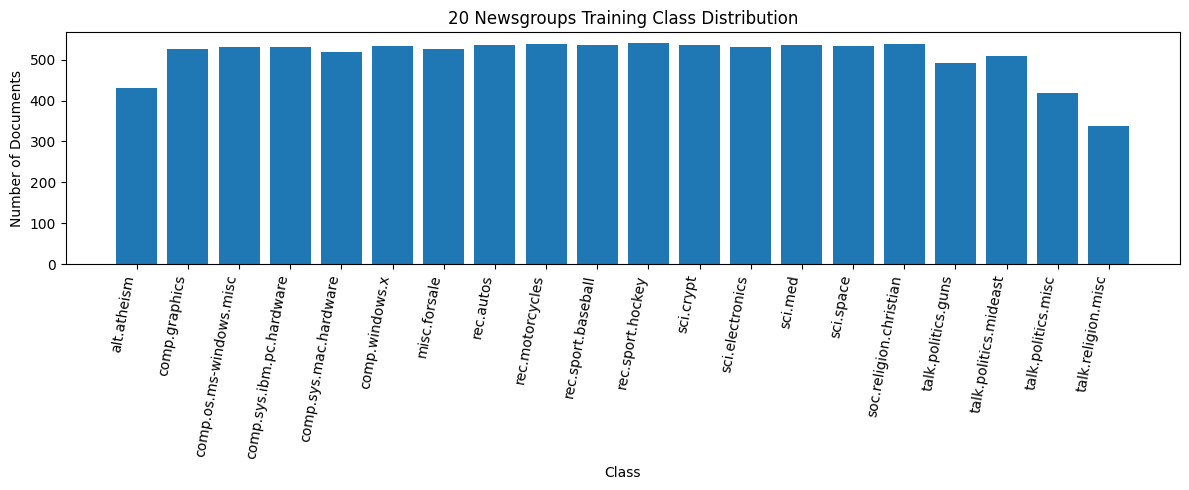

Class: alt.atheism

Actually, the story goes that Lucifer refused to bow before MAN as 
God commanded him to.  Lucifer was devoted to God.

Oh yeah, there is nothing in Genesis that says the snake was anything
more than a snake (well, a talking one...had legs at the time, too).

I don't think pointing out contradictions in STORIES is the best way
to show the error in theology:  if they think a supernatural entity
kicked the first humans out of paradise because they bit into a
fruit that gave them special powers...well, they might not respond
well to reason and logic.  :^)

Class: comp.graphics
Has anybody made a converter from irit's .irt or .dat format to
 .pov format ?

Thanks!


Class: comp.os.ms-windows.misc
Hi all,

I have a DLL in which I Register a class and create a window of that
class type.  Both calls require a module instance handle, hInstance.

Petzold's 3.1 book says that it is best to use the module instance
handle of the calling program, not the module instance handle o

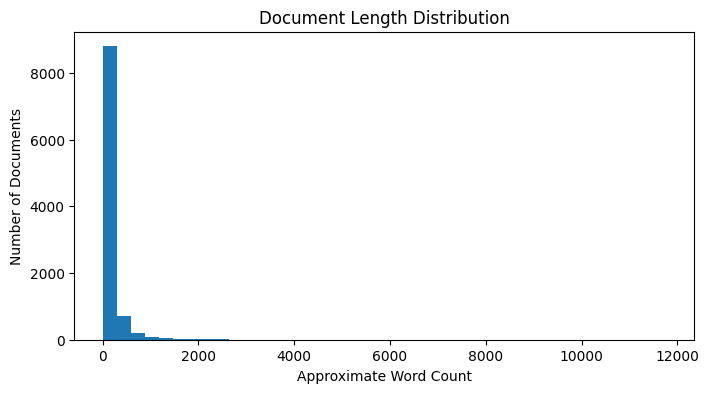

In [3]:
classes, counts = np.unique(train_labels, return_counts=True)

plt.figure(figsize=(12, 5))
plt.bar(classes, counts)
plt.xlabel("Class")
plt.ylabel("Number of Documents")
plt.title("20 Newsgroups Training Class Distribution")
plt.xticks(classes, class_names, rotation=80, ha="right")
plt.tight_layout()
plt.show()

for label in range(min(4, len(class_names))):
    idx = np.where(train_labels == label)[0][0]
    print("=" * 100)
    print("Class:", class_names[label])
    print(train_texts[idx][:700])
    print()

sample_lengths = [
    len(text.split())
    for text in train_texts[:10000]
]

plt.figure(figsize=(8, 4))
plt.hist(sample_lengths, bins=40)
plt.xlabel("Approximate Word Count")
plt.ylabel("Number of Documents")
plt.title("Document Length Distribution")
plt.show()

## 4. Preprocess the Text

Convert the raw documents into fixed-length integer sequences. The vocabulary is learned only from the training data.

In [4]:
max_tokens = 20000
sequence_length = 128 # Reduced to decrease model capacity

vectorizer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize="lower_and_strip_punctuation"
)

vectorizer.adapt(
    tf.data.Dataset.from_tensor_slices(train_texts).batch(256)
)

vocabulary_size = len(vectorizer.get_vocabulary())

print("Vocabulary Size:", vocabulary_size)
print("Sequence Length:", sequence_length)

Vocabulary Size: 20000
Sequence Length: 128


## 5. Create TensorFlow Input Pipelines

Build shuffled training and batched validation and test datasets so the Transformer can train efficiently.

In [5]:
batch_size = 64

print("Training Samples:", len(train_texts))
print("Validation Samples:", len(val_texts))
print("Test Samples:", len(test_texts))
print("Batch Size:", batch_size)

Training Samples: 10182
Validation Samples: 1132
Test Samples: 7532
Batch Size: 64


## 6. Build the Transformer Encoder

Construct token embeddings, learned positional embeddings, multi-head self-attention, residual connections, layer normalization, and the feed-forward subnetwork.

In [6]:
from tensorflow.keras.optimizers import AdamW

embedding_dim = 96  # Reduced from 128
num_heads = 4
ff_dim = 192       # Reduced from 256
dropout_rate = 0.3 # Increased from 0.1 for stronger regularization

class TokenAndPositionEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, sequence_length, embedding_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim)
        self.position_embedding = Embedding(input_dim=sequence_length, output_dim=embedding_dim)
        self.sequence_length = sequence_length

    def call(self, inputs):
        positions = tf.range(start=0, limit=self.sequence_length, delta=1)
        token_embeddings = self.token_embedding(inputs)
        position_embeddings = self.position_embedding(positions)
        return token_embeddings + position_embeddings

class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, embedding_dim, num_heads, ff_dim, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.attention = MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim // num_heads)
        self.feed_forward = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embedding_dim)
        ])
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.dropout1 = Dropout(dropout_rate)
        self.dropout2 = Dropout(dropout_rate)

    def call(self, inputs, training=False):
        attention_output = self.attention(query=inputs, value=inputs, key=inputs, training=training)
        attention_output = self.dropout1(attention_output, training=training)
        x = self.norm1(inputs + attention_output)
        feed_forward_output = self.feed_forward(x, training=training)
        feed_forward_output = self.dropout2(feed_forward_output, training=training)
        return self.norm2(x + feed_forward_output)

text_input = Input(shape=(), dtype=tf.string, name="text_input")
token_ids = vectorizer(text_input)

x = TokenAndPositionEmbedding(vocabulary_size, sequence_length, embedding_dim)(token_ids)
x = TransformerEncoder(embedding_dim, num_heads, ff_dim, dropout_rate)(x)
x = GlobalAveragePooling1D()(x)
x = Dropout(dropout_rate)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(dropout_rate)(x)

output = Dense(len(class_names), activation="softmax", name="classifier")(x)

transformer_model = Model(inputs=text_input, outputs=output)

# Using AdamW with weight decay and constant learning rate
transformer_model.compile(
    optimizer=AdamW(learning_rate=5e-4, weight_decay=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transformer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)         │ (None)                 │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 128)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 128, 96)        │     1,932,288 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 128, 96)        │        74,784 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 96)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Dense)              │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,022,068 (7.71 MB)

 Trainable params: 2,022,068 (7.71 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Transformer

Train the encoder while monitoring validation loss and restore the weights from the best validation epoch.

In [7]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Prepare datasets with the new sequence length
train_data = tf.data.Dataset.from_tensor_slices(
    (train_texts, train_labels)
).shuffle(len(train_texts)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_data = tf.data.Dataset.from_tensor_slices(
    (val_texts, val_labels)
).batch(batch_size).prefetch(tf.data.AUTOTUNE)

history = transformer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20, # Increased max epochs as weight decay might slow initial convergence
    callbacks=[early_stopping]
)

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
print(f"Best Epoch: {best_epoch}")

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.0878 - loss: 2.9547 - val_accuracy: 0.1793 - val_loss: 2.7675
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.2109 - loss: 2.4982 - val_accuracy: 0.3595 - val_loss: 2.0274
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.4574 - loss: 1.6344 - val_accuracy: 0.5972 - val_loss: 1.3034
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.7037 - loss: 0.9613 - val_accuracy: 0.6652 - val_loss: 1.1538
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8207 - loss: 0.5981 - val_accuracy: 0.6837 - val_loss: 1.3277
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8798 - loss: 0.3933 - val_accuracy: 0.6952 - val_loss: 1.3859
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9256 - loss: 0.2622 - val_accuracy: 0.6820 - val_loss: 1.5898
Best Epoch: 4


## 8. Training Curves

Visualize training and validation accuracy and loss to assess convergence and overfitting.

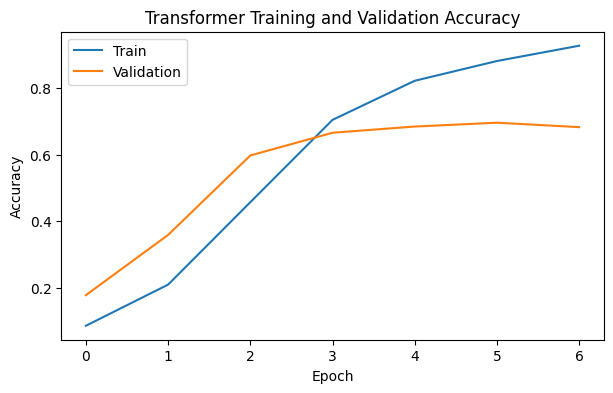

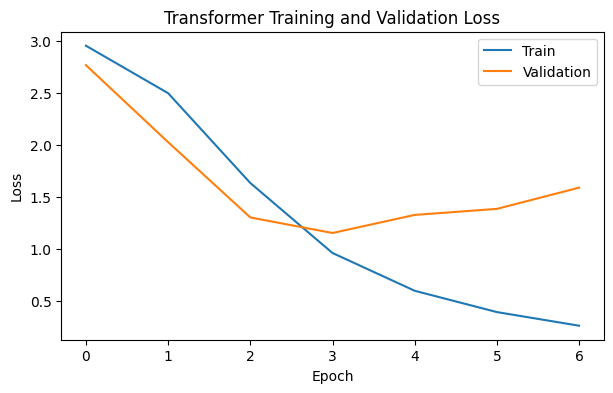

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(
    history.history["accuracy"],
    label="Train"
)
plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transformer Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(
    history.history["loss"],
    label="Train"
)
plt.plot(
    history.history["val_loss"],
    label="Validation"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Transformer Training and Validation Loss")
plt.legend()
plt.show()

## 9. Evaluate the Model

Evaluate the restored best model on the held-out 20 Newsgroups test set and generate predictions.

In [ ]:
# Using tf.data.Dataset for memory efficiency and to handle string tensors correctly
test_dataset = tf.data.Dataset.from_tensor_slices((test_texts, test_labels)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Evaluating and predicting on test set...")
# Evaluate returns loss and accuracy metrics
test_loss, test_accuracy = transformer_model.evaluate(test_dataset, verbose=1)

# Predict returns the softmax probabilities
probabilities = transformer_model.predict(test_dataset, verbose=1)
predictions = np.argmax(probabilities, axis=1)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print("Prediction Count:", len(predictions))

## 10. Classification Report

Measure precision, recall and F1-score across all twenty newsgroup categories.

In [ ]:
print(
    classification_report(
        test_labels,
        predictions,
        target_names=class_names,
        digits=4
    )
)

## 11. Confusion Matrix

Visualize class-level errors to identify categories that are frequently confused.

In [ ]:
cm = confusion_matrix(
    test_labels,
    predictions
)

fig, ax = plt.subplots(
    figsize=(12, 11)
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=90,
    values_format="d"
)

plt.title("20 Newsgroups Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. Error Analysis

Inspect representative misclassified documents to understand typical failure cases.

In [ ]:
misclassified = np.where(
    predictions != test_labels
)[0]

sample_indices = misclassified[:8]

for idx in sample_indices:
    print("=" * 100)
    print(
        "True Label     :",
        class_names[test_labels[idx]]
    )
    print(
        "Predicted Label:",
        class_names[predictions[idx]]
    )
    print("Document:")
    print(test_texts[idx][:1200])
    print()

## 13. Key Findings



## 14. Conclusion

